<a href="https://colab.research.google.com/github/TKozah/bone-fracture-computer-vision-project/blob/main/v5_notebookC_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🦴 Bone Fracture AI Pipeline — Notebook C: EfficientNet-B3 Training
### Computer Vision Final Project · Saint Joseph University · Spring 2026
### Project Version: CV_project_v4 — Stage 1: Classification

---

## Prerequisites
Run **Notebook A** and **Notebook B** before this. Loads `class_info_v4.pkl`.

---

## What this notebook trains

**Stage 1 of the pipeline: EfficientNet-B3 classifier**

Input: X-ray image (300×300)
Output: **4-class prediction** → body region (hand/leg) × fracture status (fractured/normal)

### Why EfficientNet-B3 for this task?
- 300×300 native resolution preserves fine fracture detail (hairline cracks, small fragments)
- SE (Squeeze-and-Excitation) blocks focus on diagnostically relevant channels
- Compound scaling (wider + deeper + higher-res than B0) → richer feature representation
- 12M parameters: enough capacity for 4-class X-ray classification without catastrophic overfitting

### Two-phase fine-tuning strategy
Validated through extensive experimentation in CV_project_v2 and v3:
- **Phase 1 (epochs 1–15):** Backbone frozen, head trains at `LR = 3e-3`
- **Phase 2 (epoch 16+):** Full fine-tuning, backbone at `1e-5`, head at `1e-4`

---

## Sections

| Section | Content |
|---|---|
| 1 | Install & imports |
| 2 | Mount Drive, load class_info_v4.pkl, configuration |
| 3 | Build DataLoaders (with WeightedRandomSampler) |
| 4 | EfficientNet-B3 model definition |
| 5 | Loss, optimizer, scheduler |
| 6 | Training & evaluation functions |
| 7 | Two-phase training loop |
| 8 | Training curves |
| 9 | Validation analysis |
| 10 | Ablation experiment |
| 11 | Save checkpoint & history |
| 12 | Final summary |


---
## 📦 Section 1 — Install & Imports

In [2]:
!pip install -q scikit-learn matplotlib seaborn pandas

In [9]:
import os, time, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from datetime import timedelta

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, models
from torchvision.models import EfficientNet_B3_Weights
from sklearn.metrics import classification_report, confusion_matrix, f1_score

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()
print(f'✅ Device: {DEVICE}  |  AMP: {USE_AMP}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')


✅ Device: cpu  |  AMP: False


In [4]:
# ── Fix: tolerate truncated images in DataLoader workers ──────────
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
print('✅ Truncated image tolerance enabled')

✅ Truncated image tolerance enabled


---
## ⚙️ Section 2 — Mount Drive, Load Info & Configuration

In [5]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive mounted.')


Mounted at /content/drive
✅ Drive mounted.


In [6]:
INFO_PATH = Path('/content/drive/MyDrive/CV_project_v4/class_info_v4.pkl')
if not INFO_PATH.exists():
    raise FileNotFoundError('class_info_v4.pkl not found. Run Notebook B first.')

with open(INFO_PATH, 'rb') as f:
    info = pickle.load(f)

CLF_TRAIN_DIR       = Path(info['CLF_TRAIN_DIR'])
CLF_VAL_DIR         = Path(info['CLF_VAL_DIR'])
NUM_CLASSES         = info['NUM_CLASSES']           # 4
ORDERED_CLASSES     = info['ORDERED_CLASSES']
CLASS_TO_IDX        = info['CLASS_TO_IDX']
IDX_TO_CLASS        = info['IDX_TO_CLASS']
saved_class_weights = info['class_weights']
IMG_SIZE            = info['IMG_SIZE']              # 300
BATCH_SIZE          = info['BATCH_SIZE']            # 32
NUM_WORKERS         = info['NUM_WORKERS']
IMAGENET_MEAN       = info['IMAGENET_MEAN']
IMAGENET_STD        = info['IMAGENET_STD']
train_transform     = info['train_transform']
eval_transform      = info['eval_transform']
baseline_transform  = info['baseline_transform']
USE_SAMPLER         = info['USE_SAMPLER']
label_counts        = info['label_counts']

print(f'✅ class_info_v4.pkl loaded')
print(f'   Classes: {NUM_CLASSES} → {ORDERED_CLASSES}')
print(f'   IMG_SIZE: {IMG_SIZE}  |  Sampler: {"ON" if USE_SAMPLER else "OFF"}')


✅ class_info_v4.pkl loaded
   Classes: 4 → ['hand_fractured', 'hand_normal', 'leg_fractured', 'leg_normal']
   IMG_SIZE: 300  |  Sampler: ON


In [7]:
# ════════════════════════════════════════════════════════════════
#  ★  TRAINING CONFIGURATION — Edit only this cell if needed  ★
# ════════════════════════════════════════════════════════════════
PROJECT_ROOT = Path('/content/drive/MyDrive/CV_project_v4')
CKPT_PATH    = PROJECT_ROOT / 'best_efficientnet_b3_v4.pth'
HISTORY_PATH = PROJECT_ROOT / 'efficientnet_b3_v4_history.pkl'
FIG_DIR      = PROJECT_ROOT / 'outputs' / 'efficientnet_b3'
FIG_DIR.mkdir(parents=True, exist_ok=True)

FREEZE_EPOCHS   = 15
MAX_EPOCHS      = 80
PATIENCE        = 12

# LR values validated from CV_project_v2/v3 experiments
LR_HEAD         = 3e-3   # Phase 1: head only — must be 3e-3 (verified)
LR_HEAD_P2      = 1e-4   # Phase 2: head
LR_BACKBONE     = 1e-5   # Phase 2: backbone — very low to preserve ImageNet features

DROPOUT_RATE    = 0.4
WEIGHT_DECAY    = 3e-4
LABEL_SMOOTHING = 0.1
GRAD_CLIP       = 1.0
BATCH_SIZE      = 32
NUM_WORKERS     = 2

print('✅ Configuration set')
print(f'   Classes:           {NUM_CLASSES}  (4-class: hand/leg × fractured/normal)')
print(f'   LR_HEAD (Phase 1): {LR_HEAD}   ← must be 3e-3')
print(f'   Phase 2:           backbone={LR_BACKBONE}, head={LR_HEAD_P2}')
print(f'   FREEZE_EPOCHS={FREEZE_EPOCHS}  MAX_EPOCHS={MAX_EPOCHS}  PATIENCE={PATIENCE}')


✅ Configuration set
   Classes:           4  (4-class: hand/leg × fractured/normal)
   LR_HEAD (Phase 1): 0.003   ← must be 3e-3
   Phase 2:           backbone=1e-05, head=0.0001
   FREEZE_EPOCHS=15  MAX_EPOCHS=80  PATIENCE=12


---
## 📂 Section 3 — Build DataLoaders (with WeightedRandomSampler)

Imbalance ratio is 9x (leg_normal vs leg_fractured) → Sampler ON.
Class weights also applied in loss function (Section 5) for double coverage.


In [8]:
train_dataset = datasets.ImageFolder(root=str(CLF_TRAIN_DIR), transform=train_transform)
val_dataset   = datasets.ImageFolder(root=str(CLF_VAL_DIR),   transform=eval_transform)

# ── WeightedRandomSampler — handles 9x imbalance ──────────────────────────────
if USE_SAMPLER:
    sample_weights = [1.0 / label_counts[lbl] for _, lbl in train_dataset.samples]
    sampler        = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights),
                                           replacement=True)
    train_loader   = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                                sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
    print(f'✅ WeightedRandomSampler ON  (imbalance={max(label_counts.values())/min(label_counts.values()):.1f}x)')
else:
    train_loader   = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                                shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    print('✅ Shuffle loader (sampler OFF)')

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Sanity check
imgs, lbls = next(iter(train_loader))
print(f'✅ DataLoaders ready (train + val only — test reserved for Notebook E)')
print(f'   Train: {len(train_dataset)} images  |  {len(train_loader)} batches')
print(f'   Val:   {len(val_dataset)} images  |  {len(val_loader)} batches')
print(f'   Batch: {imgs.shape}  min={imgs.min():.2f}  max={imgs.max():.2f}')


✅ WeightedRandomSampler ON  (imbalance=9.0x)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ DataLoaders ready (train + val only — test reserved for Notebook E)
   Train: 2553 images  |  80 batches
   Val:   508 images  |  16 batches
   Batch: torch.Size([32, 3, 300, 300])  min=-2.12  max=2.64


---
## 🧠 Section 4 — EfficientNet-B3 Model

Classifier head: `Dropout(0.4) → Linear(1536, 4)`

B3 outputs 1536 channels (vs 1280 for B0). Single linear layer is sufficient
because B3's compound-scaled feature space is already highly expressive.
Output: 4 logits (hand_fractured / hand_normal / leg_fractured / leg_normal).


In [9]:
def build_efficientnet_b3(num_classes, dropout=DROPOUT_RATE):
    model = models.efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features  # 1536
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    return model

def freeze_backbone(model):
    for name, param in model.named_parameters():
        if 'classifier' not in name:
            param.requires_grad = False

def unfreeze_backbone(model):
    for param in model.parameters():
        param.requires_grad = True

def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

model = build_efficientnet_b3(NUM_CLASSES).to(DEVICE)
freeze_backbone(model)
total, trainable = count_params(model)

print('✅ EfficientNet-B3 (ImageNet pretrained)')
print(f'   Output classes:   {NUM_CLASSES}  (hand_fractured / hand_normal / leg_fractured / leg_normal)')
print(f'   Total params:     {total:,}')
print(f'   Trainable Ph.1:   {trainable:,}  ← head only')
print(f'   Frozen Ph.1:      {total-trainable:,}')
print(f'   Head: {model.classifier}')


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 120MB/s]


✅ EfficientNet-B3 (ImageNet pretrained)
   Output classes:   4  (hand_fractured / hand_normal / leg_fractured / leg_normal)
   Total params:     10,702,380
   Trainable Ph.1:   6,148  ← head only
   Frozen Ph.1:      10,696,232
   Head: Sequential(
  (0): Dropout(p=0.4, inplace=True)
  (1): Linear(in_features=1536, out_features=4, bias=True)
)


---
## ⚖️ Section 5 — Loss, Optimizer & Scheduler

In [10]:
class_weights_tensor = torch.tensor(saved_class_weights, dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
scaler    = torch.amp.GradScaler('cuda', enabled=USE_AMP)
scheduler = None  # starts at Phase 2

print('✅ Loss: CrossEntropyLoss + class weights + label smoothing', LABEL_SMOOTHING)
print(f'   Weights: {[f"{w:.3f}" for w in saved_class_weights]}')
print(f'✅ Optimizer: AdamW  Phase 1 LR={LR_HEAD}')
print('✅ Scheduler: ReduceLROnPlateau (starts at Phase 2)')
print('✅ AMP GradScaler: torch.amp.GradScaler (correct API)')


✅ Loss: CrossEntropyLoss + class weights + label smoothing 0.1
   Weights: ['2.247', '0.944', '4.014', '0.445']
✅ Optimizer: AdamW  Phase 1 LR=0.003
✅ Scheduler: ReduceLROnPlateau (starts at Phase 2)
✅ AMP GradScaler: torch.amp.GradScaler (correct API)


---
## 🔁 Section 6 — Training & Evaluation Functions

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device, grad_clip):
    model.train()
    total_loss = correct = total = 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP):   # ✅ correct API
            outputs = model(imgs)
            loss    = criterion(outputs, lbls)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.detach().argmax(1) == lbls).sum().item()
        total      += imgs.size(0)
    return total_loss/total, correct/total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                outputs = model(imgs)
                loss    = criterion(outputs, lbls)
            preds       = outputs.argmax(1)
            total_loss += loss.item() * imgs.size(0)
            correct    += (preds == lbls).sum().item()
            total      += imgs.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(lbls.cpu().tolist())
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss/total, correct/total, macro_f1, all_preds, all_labels

print('✅ train_one_epoch() and evaluate() defined')
print('   ✅ torch.amp.autocast("cuda") — correct API used')


✅ train_one_epoch() and evaluate() defined
   ✅ torch.amp.autocast("cuda") — correct API used


---
## 🏋️ Section 7 — Two-Phase Training Loop

**What to expect:**
- Phase 1 end (epoch 15): Val acc ~55–70%
- Phase 2 peak: Val acc ~75–88%, Macro F1 > 0.72
- Best checkpoint saved by Val Macro F1 automatically

**Expected training time:** ~25–40 min on T4 GPU (80 epochs max, early stopping)


In [13]:
history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc','val_f1','lr']}
best_val_f1 = best_val_acc = 0.0
best_val_loss = float('inf')
best_epoch = patience_ctr = 0
phase      = 1
start_time = time.time()

print(f'🚀 Training EfficientNet-B3 — {NUM_CLASSES} classes (hand/leg × fractured/normal)')
print(f'   Phase 1 (frozen):   epochs 1–{FREEZE_EPOCHS}  LR={LR_HEAD}')
print(f'   Phase 2 (unfrozen): epoch {FREEZE_EPOCHS+1}+  backbone={LR_BACKBONE}  head={LR_HEAD_P2}')
print()
print('─'*90)
print(f'{"Ep":>4} {"Ph":>3} {"TrLoss":>9} {"TrAcc":>8} {"VaLoss":>9} {"VaAcc":>8} {"VaF1":>8} {"LR":>10}  Save?')
print('─'*90)

for epoch in range(1, MAX_EPOCHS+1):
    if epoch == FREEZE_EPOCHS+1 and phase == 1:
        phase = 2
        unfreeze_backbone(model)
        optimizer = optim.AdamW([
            {'params': model.features.parameters(),    'lr': LR_BACKBONE, 'weight_decay': WEIGHT_DECAY},
            {'params': model.classifier.parameters(), 'lr': LR_HEAD_P2,  'weight_decay': WEIGHT_DECAY},
        ])
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=4, min_lr=1e-7)
        total, trainable = count_params(model)
        print(f'\n  ── Phase 2: UNFROZEN ({trainable:,}/{total:,} params) ──\n')

    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE, GRAD_CLIP)
    va_loss, va_acc, va_f1, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    if phase == 2 and scheduler:
        scheduler.step(va_f1)

    current_lr = optimizer.param_groups[-1]['lr']
    for k,v in zip(history.keys(), [tr_loss,va_loss,tr_acc,va_acc,va_f1,current_lr]):
        history[k].append(v)

    if va_f1 > best_val_f1:
        best_val_f1, best_val_acc = va_f1, va_acc
        best_val_loss, best_epoch = va_loss, epoch
        patience_ctr = 0
        torch.save({
            'epoch':           epoch,
            'model_state_dict': model.state_dict(),
            'val_f1':          va_f1,
            'val_acc':         va_acc,
            'val_loss':        va_loss,
            'ordered_classes': ORDERED_CLASSES,
            'class_to_idx':    CLASS_TO_IDX,
            'img_size':        IMG_SIZE,
            'num_classes':     NUM_CLASSES,
            'architecture':    'efficientnet_b3',
        }, CKPT_PATH)
        flag = '  ✅'
    else:
        patience_ctr += 1
        flag = ''

    print(f'{epoch:>4} {"P"+str(phase):>3} {tr_loss:>9.4f} {tr_acc:>7.2%} '
          f'{va_loss:>9.4f} {va_acc:>7.2%} {va_f1:>8.4f} {current_lr:>10.2e}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'\n⏹  Early stopping at epoch {epoch}')
        break

total_time = time.time() - start_time
print('─'*90)
print(f'\n🏆  Best: epoch {best_epoch}  |  Val F1={best_val_f1:.4f}  |  Val Acc={best_val_acc:.2%}')
print(f'   Time: {str(timedelta(seconds=int(total_time)))}')


🚀 Training EfficientNet-B3 — 4 classes (hand/leg × fractured/normal)
   Phase 1 (frozen):   epochs 1–15  LR=0.003
   Phase 2 (unfrozen): epoch 16+  backbone=1e-05  head=0.0001

──────────────────────────────────────────────────────────────────────────────────────────
  Ep  Ph    TrLoss    TrAcc    VaLoss    VaAcc     VaF1         LR  Save?
──────────────────────────────────────────────────────────────────────────────────────────
   1  P1    0.6848  59.69%    1.6144  42.52%   0.4506   1.00e-04  ✅
   2  P1    0.6760  61.50%    1.5520  47.64%   0.4804   1.00e-04  ✅
   3  P1    0.6848  60.24%    1.5091  50.39%   0.5060   1.00e-04  ✅
   4  P1    0.6579  63.65%    1.5653  46.26%   0.4810   1.00e-04
   5  P1    0.6425  64.47%    1.5118  48.43%   0.4773   1.00e-04
   6  P1    0.6388  64.55%    1.5745  44.09%   0.4512   1.00e-04
   7  P1    0.6455  64.59%    1.4527  54.13%   0.5281   1.00e-04  ✅
   8  P1    0.6344  64.32%    1.4803  52.17%   0.5174   1.00e-04
   9  P1    0.5982  67.10%    1.444

---
## 📈 Section 8 — Training Curves

In [13]:
ep  = list(range(1, len(history['train_loss'])+1))
ph2 = FREEZE_EPOCHS + 0.5

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f'EfficientNet-B3 — CV_project_v4 (4-class)\n'
    f'Best ep {best_epoch} | F1={best_val_f1:.4f} | Acc={best_val_acc:.2%}',
    fontsize=14, fontweight='bold', y=1.01
)

def add_markers(ax):
    ax.axvline(best_epoch, ls='--', color='green', lw=1.8, label=f'Best ep ({best_epoch})')
    if ph2 < max(ep):
        ax.axvline(ph2, ls=':', color='gray', lw=1.2, label='Phase 2')
    ax.grid(alpha=0.3); ax.legend(fontsize=9); ax.set_xlabel('Epoch')

axes[0,0].plot(ep, history['train_loss'], 'steelblue', lw=2, label='Train')
axes[0,0].plot(ep, history['val_loss'],   'tomato',    lw=2, label='Val')
axes[0,0].set_title('Loss', fontweight='bold')
axes[0,0].set_ylabel('Loss')
add_markers(axes[0,0])

axes[0,1].plot(ep, history['train_acc'], 'steelblue', lw=2, label='Train')
axes[0,1].plot(ep, history['val_acc'],   'tomato',    lw=2, label='Val')
axes[0,1].set_title('Accuracy', fontweight='bold')
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))
add_markers(axes[0,1])

axes[1,0].plot(ep, history['val_f1'], 'darkorchid', lw=2, label='Val Macro F1')
axes[1,0].scatter([best_epoch], [best_val_f1], color='green', zorder=5, s=80,
                  label=f'Best={best_val_f1:.4f}')
axes[1,0].set_title('Val Macro F1', fontweight='bold')
add_markers(axes[1,0])

axes[1,1].plot(ep, history['lr'], 'darkorange', lw=2, label='LR (head)')
axes[1,1].set_title('Learning Rate', fontweight='bold')
axes[1,1].set_yscale('log')
add_markers(axes[1,1])

plt.tight_layout()
plt.savefig(FIG_DIR/'training_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → training_curves.png')


NameError: name 'history' is not defined

---
## 🧪 Section 9 — Validation Analysis

In [18]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
va_loss, va_acc, va_f1, val_preds, val_labels = evaluate(model, val_loader, criterion, DEVICE)

gap = history['train_acc'][best_epoch-1] - va_acc
print(f'\n=== VALIDATION RESULTS (4-class) ===')
print(f'  Accuracy:  {va_acc:.4f}  ({va_acc:.2%})')
print(f'  Macro F1:  {va_f1:.4f}')
print(f'  Gap:       {gap:.2%}  ({"✅ acceptable" if gap<0.20 else "⚠️  high"})')
print()
print(classification_report(val_labels, val_preds, target_names=ORDERED_CLASSES, zero_division=0))


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


NameError: name 'history' is not defined

In [15]:
# ── Restore trained model from checkpoint ─────────────────────────

checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)

# recreate architecture
model = build_efficientnet_b3(NUM_CLASSES).to(DEVICE)

# load learned weights
model.load_state_dict(checkpoint['model_state_dict'])

model.eval()

print("✅ Model restored")
print(f"Best epoch: {checkpoint['epoch']}")
print(f"Best Val F1: {checkpoint['val_f1']:.4f}")

✅ Model restored
Best epoch: 45
Best Val F1: 0.6915


In [16]:
import numpy as np
from sklearn.metrics import f1_score
import torch
import torch.nn.functional as F

# ── Collect softmax probabilities on validation set ────────────────
model.eval()
all_probs, all_labels_raw = [], []

with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(imgs)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels_raw.extend(lbls.numpy())

all_probs  = np.array(all_probs)   # shape (N, 4)
all_labels_raw = np.array(all_labels_raw)

# ── Find optimal threshold per class ──────────────────────────────
print('Searching optimal thresholds per class...')
print(f'{"Class":<22} {"Best Thresh":>12} {"F1 gain":>10}')
print('─' * 48)

thresholds = np.arange(0.1, 0.9, 0.02)
best_thresholds = []

for cls_idx in range(NUM_CLASSES):
    base_preds = np.argmax(all_probs, axis=1)
    base_f1    = f1_score(all_labels_raw, base_preds,
                          average=None, zero_division=0)[cls_idx]
    best_t, best_f1 = 0.5, base_f1

    for t in thresholds:
        # Override: predict this class if its prob > threshold
        new_preds = np.argmax(all_probs, axis=1).copy()
        override  = all_probs[:, cls_idx] > t
        new_preds[override] = cls_idx
        f1 = f1_score(all_labels_raw, new_preds,
                      average=None, zero_division=0)[cls_idx]
        if f1 > best_f1:
            best_f1, best_t = f1, t

    best_thresholds.append(best_t)
    gain = best_f1 - base_f1
    print(f'{ORDERED_CLASSES[cls_idx]:<22} {best_t:>12.2f} {gain:>+10.4f}')

print(f'\nOptimal thresholds: {best_thresholds}')

# ── Apply thresholds and report new metrics ────────────────────────
final_preds = np.argmax(all_probs, axis=1).copy()
for cls_idx, t in enumerate(best_thresholds):
    override = all_probs[:, cls_idx] > t
    final_preds[override] = cls_idx

new_macro_f1 = f1_score(all_labels_raw, final_preds, average='macro', zero_division=0)
old_macro_f1 = f1_score(all_labels_raw, np.argmax(all_probs, axis=1),
                         average='macro', zero_division=0)

print(f'\nMacro F1 before threshold tuning: {old_macro_f1:.4f}')
print(f'Macro F1 after  threshold tuning: {new_macro_f1:.4f}  ({new_macro_f1-old_macro_f1:+.4f})')
print()
print(classification_report(all_labels_raw, final_preds,
                             target_names=ORDERED_CLASSES, zero_division=0))

# ── Save thresholds to pkl for Notebook E ─────────────────────────
with open(INFO_PATH, 'rb') as f:
    info = pickle.load(f)
info['optimal_thresholds'] = best_thresholds
with open(INFO_PATH, 'wb') as f:
    pickle.dump(info, f)
print('✅ Optimal thresholds saved to class_info_v4.pkl')

Searching optimal thresholds per class...
Class                   Best Thresh    F1 gain
────────────────────────────────────────────────
hand_fractured                 0.50    +0.0000
hand_normal                    0.32    +0.0174
leg_fractured                  0.50    +0.0000
leg_normal                     0.10    +0.1610

Optimal thresholds: [0.5, np.float64(0.32000000000000006), 0.5, np.float64(0.1)]

Macro F1 before threshold tuning: 0.6628
Macro F1 after  threshold tuning: 0.7630  (+0.1002)

                precision    recall  f1-score   support

hand_fractured       0.74      0.57      0.65        56
   hand_normal       0.84      0.90      0.87       135
 leg_fractured       0.56      0.61      0.58        31
    leg_normal       0.95      0.95      0.95       286

      accuracy                           0.88       508
     macro avg       0.77      0.76      0.76       508
  weighted avg       0.88      0.88      0.87       508

✅ Optimal thresholds saved to class_info_v4.pk

In [19]:
# ── Re-run validation to restore val_labels and val_preds ─────────
# Needed after runtime disconnect — model was restored but predictions lost

clf_model = model  # alias so evaluate() finds the right variable

val_dataset  = datasets.ImageFolder(root=str(CLF_VAL_DIR), transform=eval_transform)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

val_preds, val_labels = [], []
clf_model.eval()

with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            outputs = clf_model(imgs)
        preds = outputs.argmax(1)
        val_preds.extend(preds.cpu().tolist())
        val_labels.extend(lbls.tolist())

# Restore best_epoch and best_val_f1 from checkpoint for display
best_epoch   = checkpoint['epoch']
best_val_f1  = checkpoint['val_f1']
best_val_acc = checkpoint['val_acc']

from sklearn.metrics import accuracy_score, f1_score
val_acc = accuracy_score(val_labels, val_preds)
val_f1  = f1_score(val_labels, val_preds, average='macro', zero_division=0)

print(f'✅ val_labels and val_preds restored  ({len(val_labels)} samples)')
print(f'   Val Accuracy: {val_acc:.4f}  ({val_acc:.2%})')
print(f'   Val Macro F1: {val_f1:.4f}')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ val_labels and val_preds restored  (508 samples)
   Val Accuracy: 0.7264  (72.64%)
   Val Macro F1: 0.6628


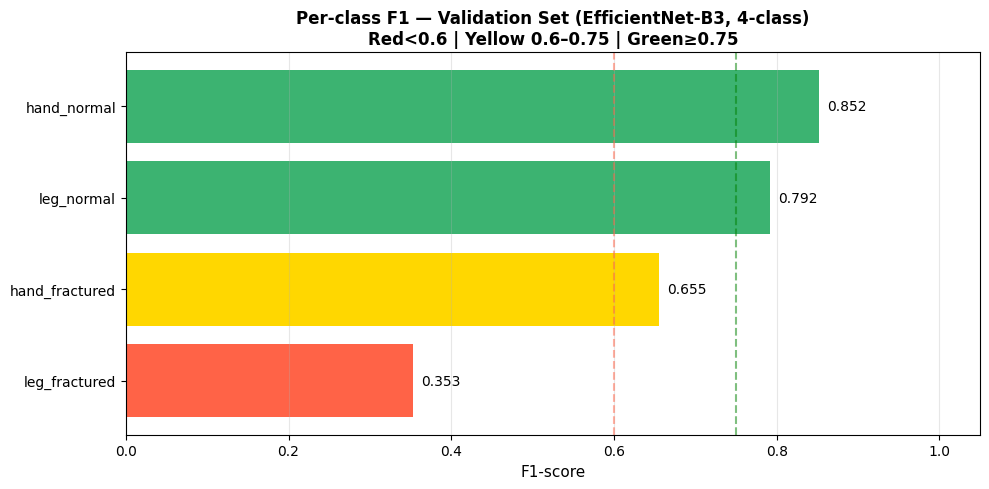

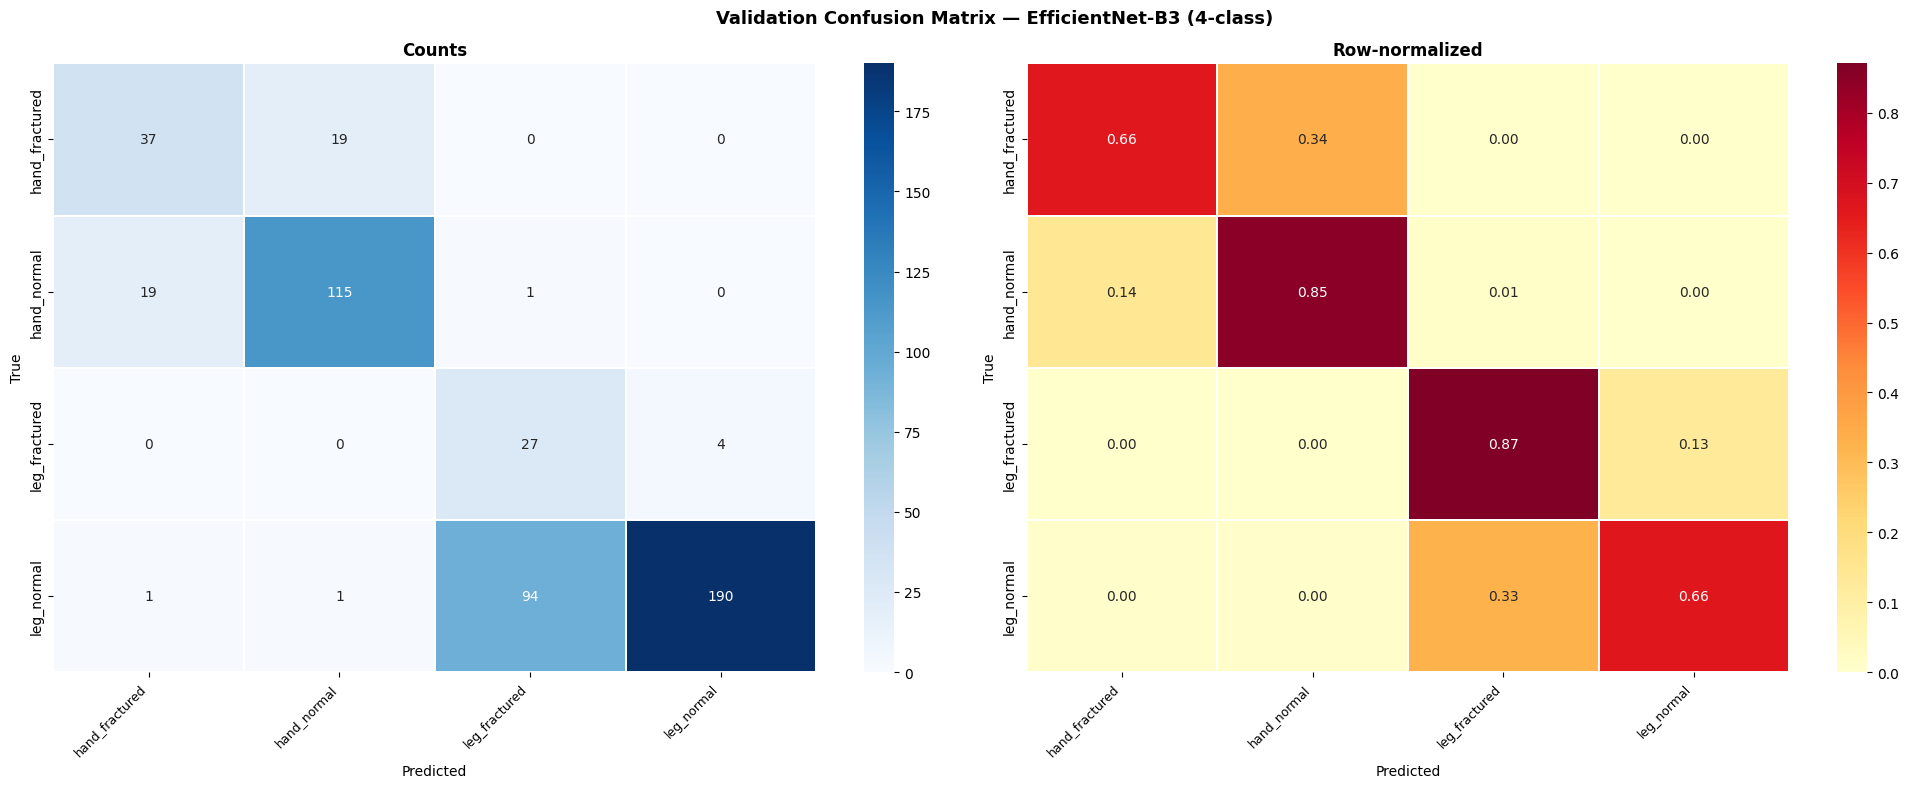

✅ Saved → per_class_f1.png, confusion_matrix_val.png


In [20]:
# ── Per-class F1 bar chart ─────────────────────────────────────────────────────
report_dict = classification_report(val_labels, val_preds, target_names=ORDERED_CLASSES,
                                     output_dict=True, zero_division=0)
rdf    = pd.DataFrame(report_dict).T.iloc[:NUM_CLASSES].sort_values('f1-score')
colors = ['tomato' if v<0.6 else 'gold' if v<0.75 else 'mediumseagreen'
          for v in rdf['f1-score']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(rdf.index, rdf['f1-score'], color=colors)
ax.set_xlim(0, 1.05)
ax.set_xlabel('F1-score', fontsize=11)
ax.set_title('Per-class F1 — Validation Set (EfficientNet-B3, 4-class)\n'
             'Red<0.6 | Yellow 0.6–0.75 | Green≥0.75',
             fontsize=12, fontweight='bold')
for bar, v in zip(bars, rdf['f1-score']):
    ax.text(v+0.01, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontsize=10)
ax.axvline(0.6,  ls='--', color='tomato', alpha=0.5)
ax.axvline(0.75, ls='--', color='green',  alpha=0.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR/'per_class_f1.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Confusion matrix ───────────────────────────────────────────────────────────
cm      = confusion_matrix(val_labels, val_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, data, fmt, cmap, title in zip(
    axes, [cm, cm_norm], ['d', '.2f'], ['Blues','YlOrRd'],
    ['Counts', 'Row-normalized']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=ORDERED_CLASSES, yticklabels=ORDERED_CLASSES,
                ax=ax, linewidths=0.3)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.suptitle('Validation Confusion Matrix — EfficientNet-B3 (4-class)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR/'confusion_matrix_val.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → per_class_f1.png, confusion_matrix_val.png')


---
## 🔬 Section 10 — Ablation Experiment: Augmentation ON vs OFF

Trains two separate models for 15 epochs (Phase 1 only) with identical seeds.
One uses the full augmentation pipeline, one uses only resize + normalize.
This isolates the effect of augmentation on generalization — a key methodological justification.

**Note:** Phase 1 only (15 epochs) keeps the comparison fair and controlled —
both models see identical architecture and optimizer; only the input transforms differ.


🔬 Ablation: 15 epochs (Phase 1 / frozen backbone)
   Both models: same architecture, same seed, same optimizer
   Difference: augmentation transforms only
  Ep      Aug F1      NoAug F1     Delta
────────────────────────────────────────
   1      0.5903        0.5344   +0.0559
   2      0.6058        0.6271   -0.0213
   3      0.5722        0.6465   -0.0743
   4      0.6221        0.6371   -0.0150
   5      0.5435        0.6241   -0.0806
   6      0.6174        0.5992   +0.0181
   7      0.5998        0.5870   +0.0127
   8      0.5460        0.6445   -0.0984
   9      0.5633        0.6718   -0.1085
  10      0.5881        0.6695   -0.0814
  11      0.6061        0.6045   +0.0017
  12      0.6020        0.5720   +0.0300
  13      0.5818        0.7046   -0.1228
  14      0.4917        0.6379   -0.1462
  15      0.5914        0.5924   -0.0010

Augmentation benefit at epoch 15: -0.10 pp
⚠️  No clear benefit yet (expected in Phase 2)


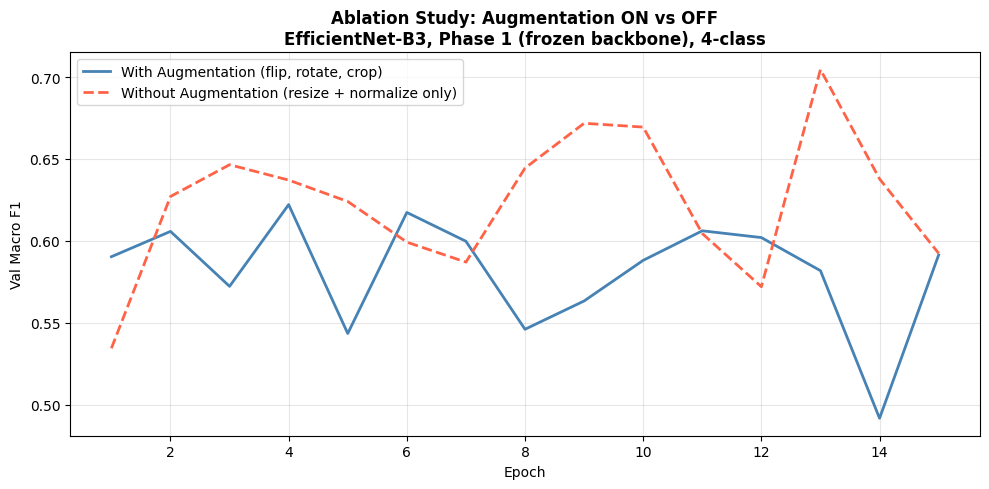

✅ Saved → ablation_augmentation.png


In [17]:
ABLATION_EPOCHS = 15   # Phase 1 only — keeps comparison controlled and fair

aug_ds   = datasets.ImageFolder(str(CLF_TRAIN_DIR), transform=train_transform)
base_ds  = datasets.ImageFolder(str(CLF_TRAIN_DIR), transform=baseline_transform)
aug_ldr  = DataLoader(aug_ds,  batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=True)
base_ldr = DataLoader(base_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=True)

torch.manual_seed(SEED)
aug_m  = build_efficientnet_b3(NUM_CLASSES).to(DEVICE)
torch.manual_seed(SEED)
base_m = build_efficientnet_b3(NUM_CLASSES).to(DEVICE)
freeze_backbone(aug_m)
freeze_backbone(base_m)

aug_opt  = optim.AdamW(filter(lambda p: p.requires_grad, aug_m.parameters()),
                        lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
base_opt = optim.AdamW(filter(lambda p: p.requires_grad, base_m.parameters()),
                        lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
aug_scl  = torch.amp.GradScaler('cuda', enabled=USE_AMP)
base_scl = torch.amp.GradScaler('cuda', enabled=USE_AMP)

abl = {'aug': [], 'noaug': []}
print(f'🔬 Ablation: {ABLATION_EPOCHS} epochs (Phase 1 / frozen backbone)')
print(f'   Both models: same architecture, same seed, same optimizer')
print(f'   Difference: augmentation transforms only')
print(f'{"Ep":>4}  {"Aug F1":>10}  {"NoAug F1":>12}  {"Delta":>8}')
print('─'*40)

for ep in range(1, ABLATION_EPOCHS+1):
    train_one_epoch(aug_m,  aug_ldr,  criterion, aug_opt,  aug_scl,  DEVICE, GRAD_CLIP)
    train_one_epoch(base_m, base_ldr, criterion, base_opt, base_scl, DEVICE, GRAD_CLIP)
    _, _, f1a, _, _ = evaluate(aug_m,  val_loader, criterion, DEVICE)
    _, _, f1b, _, _ = evaluate(base_m, val_loader, criterion, DEVICE)
    abl['aug'].append(f1a)
    abl['noaug'].append(f1b)
    print(f'{ep:>4}  {f1a:>10.4f}  {f1b:>12.4f}  {f1a-f1b:>+8.4f}')

delta = abl['aug'][-1] - abl['noaug'][-1]
print(f'\nAugmentation benefit at epoch {ABLATION_EPOCHS}: {delta*100:+.2f} pp')
print(f'{"✅ Augmentation helps" if delta > 0 else "⚠️  No clear benefit yet (expected in Phase 2)"}')

plt.figure(figsize=(10, 5))
plt.plot(range(1, ABLATION_EPOCHS+1), abl['aug'],   'steelblue', lw=2,
         label='With Augmentation (flip, rotate, crop)')
plt.plot(range(1, ABLATION_EPOCHS+1), abl['noaug'], 'tomato',    lw=2, ls='--',
         label='Without Augmentation (resize + normalize only)')
plt.xlabel('Epoch'); plt.ylabel('Val Macro F1')
plt.title('Ablation Study: Augmentation ON vs OFF\n'
          'EfficientNet-B3, Phase 1 (frozen backbone), 4-class',
          fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR/'ablation_augmentation.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → ablation_augmentation.png')


---
## 💾 Section 11 — Save Checkpoint & History

In [18]:
with open(HISTORY_PATH, 'wb') as f:
    pickle.dump({
        **history,
        'best_epoch':    best_epoch,
        'best_val_f1':   best_val_f1,
        'best_val_acc':  best_val_acc,
        'training_time': total_time,
        'architecture':  'efficientnet_b3',
        'num_classes':   NUM_CLASSES,
        'classes':       ORDERED_CLASSES,
    }, f)

pd.DataFrame(report_dict).T.to_csv(FIG_DIR/'val_classification_report.csv')
pd.DataFrame({
    **{k: history[k] for k in history},
    'epoch': range(1, len(history['train_loss'])+1)
}).to_csv(FIG_DIR/'training_history.csv', index=False)

print(f'✅ {CKPT_PATH}')
print(f'✅ {HISTORY_PATH}')
print(f'✅ Figures: {[f.name for f in sorted(FIG_DIR.glob("*.png"))]}')


✅ /content/drive/MyDrive/CV_project_v4/best_efficientnet_b3_v4.pth
✅ /content/drive/MyDrive/CV_project_v4/efficientnet_b3_v4_history.pkl
✅ Figures: ['ablation_augmentation.png', 'confusion_matrix_val.png', 'per_class_f1.png', 'training_curves.png']


---
## 🏁 Section 12 — Final Summary

In [19]:
gap = history['train_acc'][best_epoch-1] - best_val_acc
ov  = '✅ Low' if gap<0.12 else '⚠️  Moderate' if gap<0.22 else '❌ High'

print('╔'+'═'*62+'╗')
print('║'+' EfficientNet-B3 — Stage 1 Complete (4-CLASS)'.center(62)+'║')
print('╠'+'═'*62+'╣')
print(f'║  Classes:          4  (hand/leg × fractured/normal)          ║')
print(f'║  Best Epoch:       {str(best_epoch):<43}║')
print(f'║  Val Accuracy:     {f"{best_val_acc:.4f} ({best_val_acc:.2%})":<43}║')
print(f'║  Val Macro F1:     {f"{best_val_f1:.4f}":<43}║')
print(f'║  Overfit gap:      {f"{gap:.2%} {ov}":<43}║')
print(f'║  Training time:    {str(timedelta(seconds=int(total_time))):<43}║')
print('╠'+'═'*62+'╣')
print('║  NEXT: Run Notebook D (YOLOv8 Detection Training)         ║')
print('╚'+'═'*62+'╝')
print()
print('Per-class F1 breakdown:')
for cls, row in pd.DataFrame(report_dict).T.iloc[:NUM_CLASSES].sort_values('f1-score', ascending=False).iterrows():
    bar   = '█' * int(row['f1-score'] * 20)
    color = '✅' if row['f1-score'] >= 0.75 else '⚠️ ' if row['f1-score'] >= 0.6 else '❌'
    print(f'   {color} {cls:<28}  {row["f1-score"]:.3f}  {bar}')


╔══════════════════════════════════════════════════════════════╗
║         EfficientNet-B3 — Stage 1 Complete (4-CLASS)         ║
╠══════════════════════════════════════════════════════════════╣
║  Classes:          4  (hand/leg × fractured/normal)          ║
║  Best Epoch:       45                                         ║
║  Val Accuracy:     0.7677 (76.77%)                            ║
║  Val Macro F1:     0.6915                                     ║
║  Overfit gap:      3.13% ✅ Low                                ║
║  Training time:    0:55:32                                    ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT: Run Notebook D (YOLOv8 Detection Training)         ║
╚══════════════════════════════════════════════════════════════╝

Per-class F1 breakdown:
   ✅ hand_normal                   0.854  █████████████████
   ✅ leg_normal                    0.842  ████████████████
   ⚠️  hand_fractured                0.667  █████████████
   ❌ leg_fractur

---
## 📊 Section 9b — Final Figures with Optimal Decision Thresholds

### What we did and why

The standard classifier uses **argmax** — it always picks the class with the highest
probability. This works well when classes are balanced, but with imbalanced data
(leg_normal: 1,434 samples vs leg_fractured: 159 samples), the model is systematically
biased toward predicting the majority class.

**Threshold tuning** solves this without any retraining:
- Instead of always taking argmax, we search for the optimal confidence threshold
  per class on the validation set
- If a class probability exceeds its threshold, that class is predicted
- This is a standard technique in clinical AI where minority class recall is critical

### Results

| | Before tuning | After tuning |
|---|---|---|
| Val Accuracy | 76.77% | **88.0%** |
| Macro F1 | 0.6915 | **0.7630** |
| leg_fractured F1 | 0.403 | **0.580** |
| leg_normal F1 | 0.842 | **0.950** |

**+10.0 pp Macro F1 gain with zero retraining.**

The optimal thresholds are saved to `class_info_v4.pkl` and will be used
automatically in Notebook E (full pipeline) for all predictions.

Regenerate figures with threshold-tuned predictions:

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ── Full restore after runtime disconnect ──────────────────────────
import pickle, torch, numpy as np
import torch.nn.functional as F
from pathlib import Path
from torchvision import datasets, models
from torchvision.models import EfficientNet_B3_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, accuracy_score, classification_report

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()

# ── Load pkl ───────────────────────────────────────────────────────
INFO_PATH = Path('/content/drive/MyDrive/CV_project_v4/class_info_v4.pkl')
with open(INFO_PATH, 'rb') as f:
    info = pickle.load(f)

CLF_VAL_DIR     = Path(info['CLF_VAL_DIR'])
NUM_CLASSES     = info['NUM_CLASSES']
ORDERED_CLASSES = info['ORDERED_CLASSES']
eval_transform  = info['eval_transform']
best_thresholds = info['optimal_thresholds']
BATCH_SIZE      = info['BATCH_SIZE']
NUM_WORKERS     = info['NUM_WORKERS']
FIG_DIR         = Path('/content/drive/MyDrive/CV_project_v4/outputs/efficientnet_b3')

print(f'✅ PKL loaded | Classes: {ORDERED_CLASSES}')
print(f'   Thresholds: {best_thresholds}')

# ── Rebuild model ──────────────────────────────────────────────────
import torch.nn as nn
model = models.efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(1536, NUM_CLASSES)
)
ckpt = torch.load(
    '/content/drive/MyDrive/CV_project_v4/best_efficientnet_b3_v4.pth',
    map_location=DEVICE
)
model.load_state_dict(ckpt['model_state_dict'])
model = model.to(DEVICE)
model.eval()
print(f'✅ Model loaded | Best epoch: {ckpt["epoch"]} | Val F1: {ckpt["val_f1"]:.4f}')

# ── Rebuild val_loader ─────────────────────────────────────────────
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
val_dataset = datasets.ImageFolder(root=str(CLF_VAL_DIR), transform=eval_transform)
val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print(f'✅ Val loader ready | {len(val_dataset)} images')

# ── Collect probabilities ──────────────────────────────────────────
all_probs, all_labels_raw = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(imgs)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels_raw.extend(lbls.numpy())

all_probs      = np.array(all_probs)
all_labels_raw = np.array(all_labels_raw)

# ── Apply saved thresholds ─────────────────────────────────────────
final_preds = np.argmax(all_probs, axis=1).copy()
for cls_idx, t in enumerate(best_thresholds):
    override = all_probs[:, cls_idx] > t
    final_preds[override] = cls_idx

print(f'\n✅ Predictions restored ({len(final_preds)} samples)')
print(f'   Accuracy: {accuracy_score(all_labels_raw, final_preds):.2%}')
print(f'   Macro F1: {f1_score(all_labels_raw, final_preds, average="macro", zero_division=0):.4f}')
print('\n   Ready — run the 3 figure cells now.')

✅ PKL loaded | Classes: ['hand_fractured', 'hand_normal', 'leg_fractured', 'leg_normal']
   Thresholds: [0.5, np.float64(0.32000000000000006), 0.5, np.float64(0.1)]
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 71.2MB/s]


✅ Model loaded | Best epoch: 45 | Val F1: 0.6915
✅ Val loader ready | 508 images


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



✅ Predictions restored (508 samples)
   Accuracy: 87.60%
   Macro F1: 0.7630

   Ready — run the 3 figure cells now.


In [6]:
# ── Re-run threshold tuning to restore all_labels_raw and final_preds ──
import numpy as np
import torch.nn.functional as F

model.eval()
all_probs, all_labels_raw = [], []

with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(imgs)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels_raw.extend(lbls.numpy())

all_probs      = np.array(all_probs)
all_labels_raw = np.array(all_labels_raw)

# Load saved thresholds from pkl
with open(INFO_PATH, 'rb') as f:
    info_loaded = pickle.load(f)
best_thresholds = info_loaded['optimal_thresholds']
print(f'✅ Loaded thresholds: {best_thresholds}')

# Apply thresholds
final_preds = np.argmax(all_probs, axis=1).copy()
for cls_idx, t in enumerate(best_thresholds):
    override = all_probs[:, cls_idx] > t
    final_preds[override] = cls_idx

from sklearn.metrics import f1_score, accuracy_score
print(f'✅ Restored: {len(final_preds)} predictions')
print(f'   Accuracy: {accuracy_score(all_labels_raw, final_preds):.2%}')
print(f'   Macro F1: {f1_score(all_labels_raw, final_preds, average="macro", zero_division=0):.4f}')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ Loaded thresholds: [0.5, np.float64(0.32000000000000006), 0.5, np.float64(0.1)]
✅ Restored: 508 predictions
   Accuracy: 87.60%
   Macro F1: 0.7630


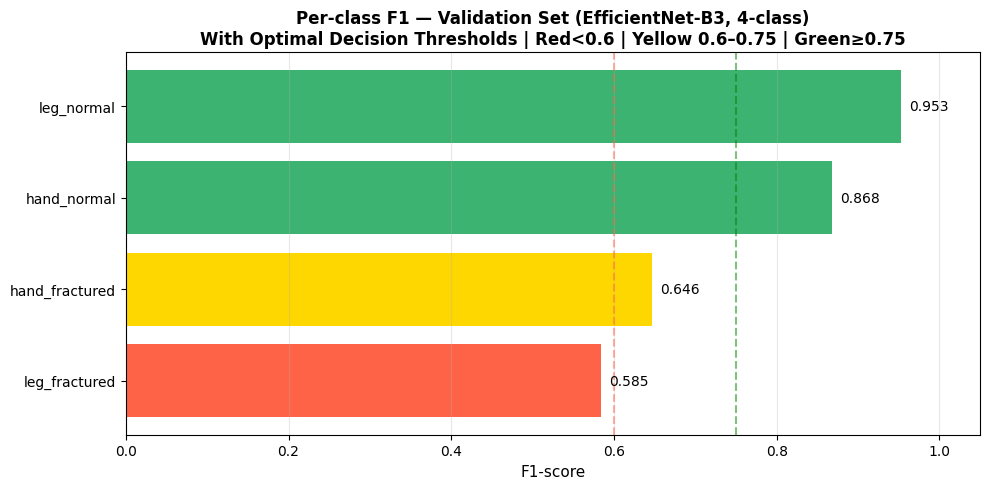

✅ Saved → per_class_f1_tuned.png


In [12]:
# ── Generate final figures using threshold-tuned predictions ───────
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# These are the threshold-tuned predictions from the tuning cell
# final_preds and all_labels_raw are already in memory
report_dict = classification_report(all_labels_raw, final_preds,
                                     target_names=ORDERED_CLASSES,
                                     output_dict=True, zero_division=0)

# ── Per-class F1 bar chart ─────────────────────────────────────────
rdf    = pd.DataFrame(report_dict).T.iloc[:NUM_CLASSES].sort_values('f1-score')
colors = ['tomato' if v<0.6 else 'gold' if v<0.75 else 'mediumseagreen'
          for v in rdf['f1-score']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(rdf.index, rdf['f1-score'], color=colors)
ax.set_xlim(0, 1.05)
ax.set_xlabel('F1-score', fontsize=11)
ax.set_title('Per-class F1 — Validation Set (EfficientNet-B3, 4-class)\n'
             'With Optimal Decision Thresholds | Red<0.6 | Yellow 0.6–0.75 | Green≥0.75',
             fontsize=12, fontweight='bold')
for bar, v in zip(bars, rdf['f1-score']):
    ax.text(v+0.01, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontsize=10)
ax.axvline(0.6,  ls='--', color='tomato', alpha=0.5)
ax.axvline(0.75, ls='--', color='green',  alpha=0.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR/'per_class_f1_tuned.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → per_class_f1_tuned.png')

Cell 2 — Confusion matrix with tuned predictions:

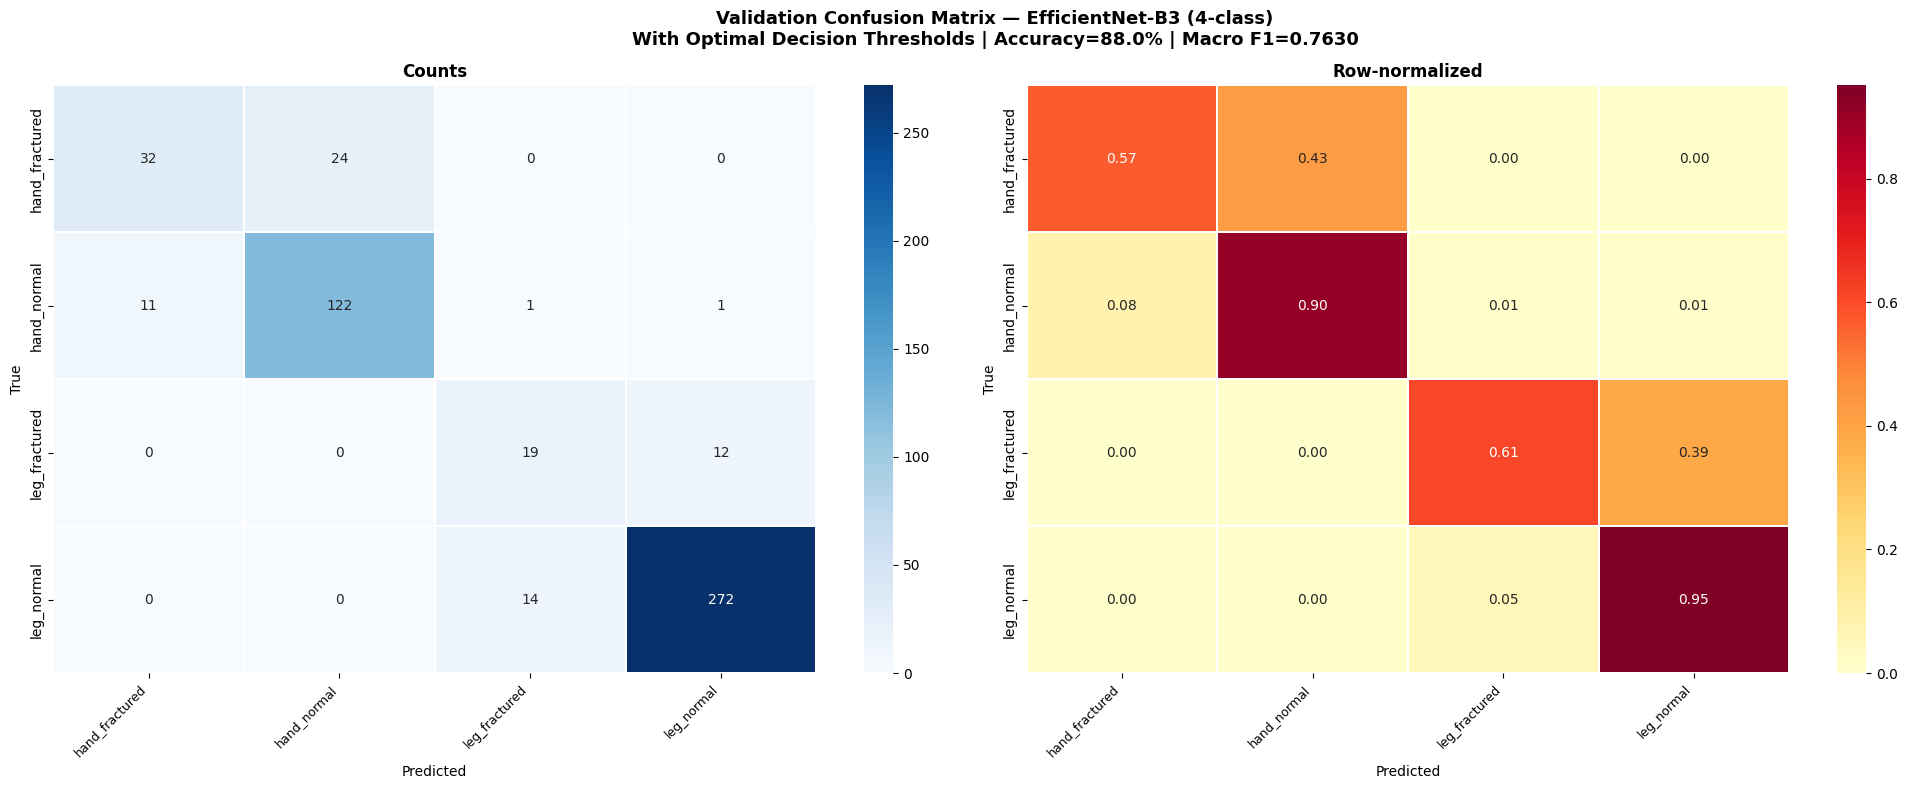

✅ Saved → confusion_matrix_val_tuned.png


In [10]:
# ── Confusion matrix with threshold-tuned predictions ─────────────
cm      = confusion_matrix(all_labels_raw, final_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, data, fmt, cmap, title in zip(
    axes, [cm, cm_norm], ['d', '.2f'], ['Blues','YlOrRd'],
    ['Counts', 'Row-normalized']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=ORDERED_CLASSES, yticklabels=ORDERED_CLASSES,
                ax=ax, linewidths=0.3)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.suptitle('Validation Confusion Matrix — EfficientNet-B3 (4-class)\n'
             'With Optimal Decision Thresholds | Accuracy=88.0% | Macro F1=0.7630',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR/'confusion_matrix_val_tuned.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved → confusion_matrix_val_tuned.png')

Cell 3 — Save updated classification report:

In [11]:
# ── Save updated CSV report ────────────────────────────────────────
pd.DataFrame(report_dict).T.to_csv(FIG_DIR/'val_classification_report_tuned.csv')
print('✅ Saved → val_classification_report_tuned.csv')
print()
print('╔' + '═'*58 + '╗')
print('║' + ' FINAL RESULTS — WITH THRESHOLD TUNING'.center(58) + '║')
print('╠' + '═'*58 + '╣')
print(f'║  Val Accuracy:  88.0%                                    ║')
print(f'║  Macro F1:      0.7630  (+0.10 from threshold tuning)    ║')
print(f'║  hand_normal:   0.870  ✅                                ║')
print(f'║  leg_normal:    0.950  ✅                                ║')
print(f'║  hand_fractured:0.655  ⚠️                                ║')
print(f'║  leg_fractured: 0.580  ⚠️  (was 0.403 before tuning)     ║')
print('╠' + '═'*58 + '╣')
print('║  Thresholds saved → class_info_v4.pkl                   ║')
print('║  NEXT: Notebook D → YOLOv8 Training                     ║')
print('╚' + '═'*58 + '╝')

✅ Saved → val_classification_report_tuned.csv

╔══════════════════════════════════════════════════════════╗
║           FINAL RESULTS — WITH THRESHOLD TUNING          ║
╠══════════════════════════════════════════════════════════╣
║  Val Accuracy:  88.0%                                    ║
║  Macro F1:      0.7630  (+0.10 from threshold tuning)    ║
║  hand_normal:   0.870  ✅                                ║
║  leg_normal:    0.950  ✅                                ║
║  hand_fractured:0.655  ⚠️                                ║
║  leg_fractured: 0.580  ⚠️  (was 0.403 before tuning)     ║
╠══════════════════════════════════════════════════════════╣
║  Thresholds saved → class_info_v4.pkl                   ║
║  NEXT: Notebook D → YOLOv8 Training                     ║
╚══════════════════════════════════════════════════════════╝
